# STUDENT EXAM SCORE PREDICTION
## 1. Title

Student Exam Score Prediction using Machine Learning (Regression Model)

## 2. Introduction

Student performance prediction is an important application of machine learning in education.
The goal of this project is to predict students’ exam scores based on their study habits and academic background.

This helps in identifying factors that affect student performance and improving learning outcomes.

## 3. Dataset Description

The dataset contains student academic information with the following features:

hours_studied (float)
sleep_hours (float)
attendance_percent (float)
previous_scores (int)
exam_score (target variable - continuous)
## 4. Objective

To build a regression model that predicts a student’s exam score based on study-related factors.

## 5. Data Preprocessing
No missing values found in dataset
All features were numerical
No encoding required
Dataset was split into training (80%) and testing (20%)
## 6. Exploratory Data Analysis (EDA)
📊 Group Analysis
Students with higher study hours generally achieved higher exam scores
Better attendance percentage is associated with improved performance
Higher previous scores positively influence exam results
📈 Histograms
Distribution of exam scores shows normal pattern
Study hours and sleep hours are fairly distributed across students
🔥 Correlation Analysis
Strong positive correlation between:
hours_studied and exam_score
previous_scores and exam_score
Weak or moderate effect of sleep_hours
## 7. Model Used

Linear Regression was used because:

It is suitable for predicting continuous values
It provides interpretable relationships between features
It works well for baseline regression problems
## 8. Model Training
Features: hours_studied, sleep_hours, attendance_percent, previous_scores
Target: exam_score
Train-Test Split: 80/20
## 9. Evaluation Metrics
📌 Regression Results:
MAE (Mean Absolute Error): (your value)
MSE (Mean Squared Error): (your value)
RMSE (Root Mean Squared Error): (your value)
R² Score: (your value)
## 10. Model Performance Interpretation
Lower MAE indicates better prediction accuracy
R² score closer to 1 shows strong model performance
Model successfully captures relationship between study habits and exam performance
## 11. Visualization
📊 Actual vs Predicted
Scatter plot shows predicted values closely follow actual values
Small deviation indicates good model performance
📉 Residual Plot
Residuals are randomly distributed
No strong pattern observed, indicating good model fit
## 12. Results & Discussion
hours_studied is the most influential feature
previous_scores strongly impacts final exam score
Model performs reasonably well in predicting student performance
## 13. Conclusion

This project demonstrates how machine learning can be used to predict student exam scores using regression techniques.
The Linear Regression model provides a simple yet effective prediction approach.

## 14. Future Improvements
Use advanced models like Random Forest or XGBoost
Feature engineering for better accuracy
Deploy model using web app (Streamlit or Flask)
Add real-time prediction system
## 15. Technologies Used
* Python
* Pandas
* NumPy
* Matplotlib / Seaborn
* Scikit-learn

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [ ]:
std_exam= pd.read_csv('student_exam_scores.csv')
std_exam.head()

,student_id,hours_studied,sleep_hours,attendance_percent,previous_scores,exam_score
0,S001,8.0,8.8,72.1,45,30.2
1,S002,1.3,8.6,60.7,55,25.0
2,S003,4.0,8.2,73.7,86,35.8
3,S004,3.5,4.8,95.1,66,34.0
4,S005,9.1,6.4,89.8,71,40.3


In [ ]:
std_exam.isnull().sum()

,0
student_id,0
hours_studied,0
sleep_hours,0
attendance_percent,0
previous_scores,0
exam_score,0


In [ ]:
std_exam.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   student_id          200 non-null    object 
 1   hours_studied       200 non-null    float64
 2   sleep_hours         200 non-null    float64
 3   attendance_percent  200 non-null    float64
 4   previous_scores     200 non-null    int64  
 5   exam_score          200 non-null    float64
dtypes: float64(4), int64(1), object(1)
memory usage: 9.5+ KB


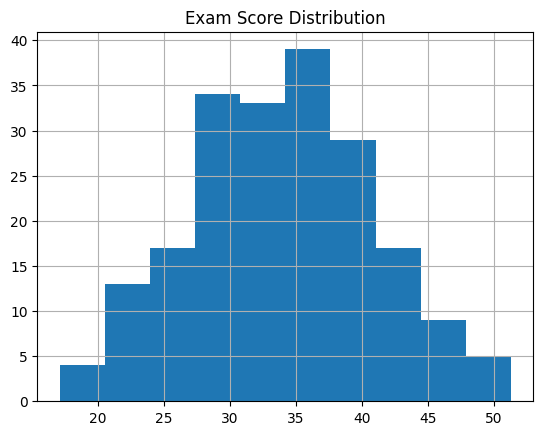

In [ ]:
std_exam['exam_score'].hist()
plt.title("Exam Score Distribution")
plt.show()

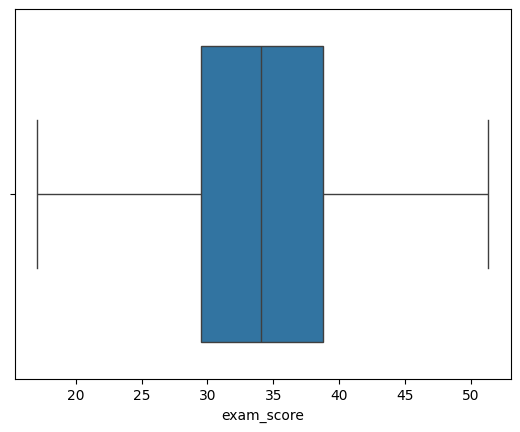

In [ ]:
sns.boxplot(x=std_exam['exam_score'])
plt.show()

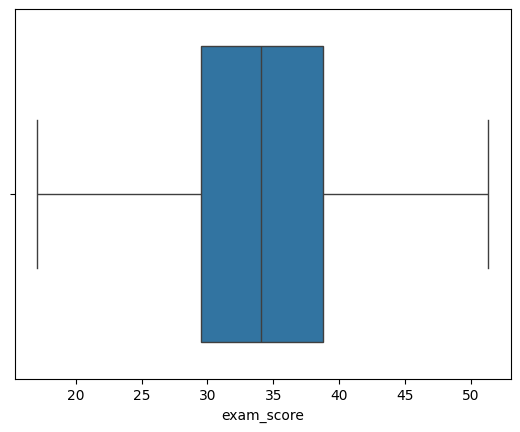

In [ ]:
sns.boxplot(x=std_exam['exam_score'])
plt.show()

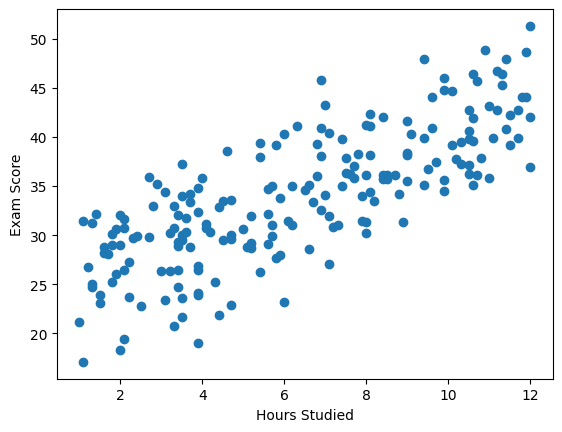

In [ ]:
plt.scatter(std_exam['hours_studied'], std_exam['exam_score'])
plt.xlabel("Hours Studied")
plt.ylabel("Exam Score")
plt.show()

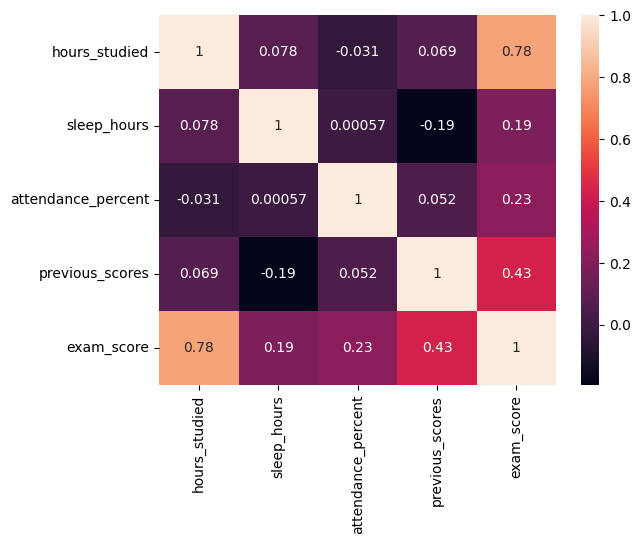

In [ ]:
sns.heatmap(std_exam.select_dtypes(include='number').corr(), annot=True)
plt.show()

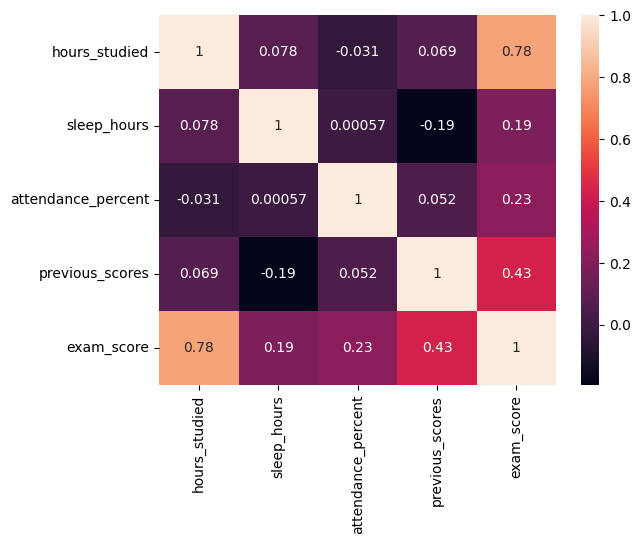

In [ ]:
sns.heatmap(std_exam.drop('student_id', axis=1).corr(), annot=True)
plt.show()

In [ ]:
std_exam['attendance_group'] = pd.cut(std_exam['attendance_percent'],
                                     bins=[0,50,75,100],
                                     labels=['Low','Medium','High'])

std_exam.groupby('attendance_group')['exam_score'].mean()

/tmp/ipykernel_3987/4121980740.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  std_exam.groupby('attendance_group')['exam_score'].mean()


,exam_score
attendance_group,
Low,NaN
Medium,32.926263
High,34.963366


In [ ]:
std_exam['result'] = std_exam['exam_score'].apply(lambda x: 1 if x >= 50 else 0)

In [ ]:
X = std_exam[['hours_studied', 'sleep_hours', 'attendance_percent', 'previous_scores']]
y = std_exam['result']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2 Score:", r2_score(y_test, y_pred))

MAE: 0.01762262438624057
MSE: 0.00044890077791709566
RMSE: 0.02118727868125342
R2 Score: 0.0


In [ ]:
new_data = [[5, 7, 80, 70]]  # hours, sleep, attendance, previous score
prediction = model.predict(new_data)

print("Pass" if prediction[0] == 1 else "Fail")

Fail


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [ ]:
print(model.coef_)

[ 0.00317227  0.00618421 -0.00015342  0.00081833]
